In [21]:
# # Advanced Model: Random Forest — Trip Duration & Congestion Fee Prediction
# 
# 
# ## Objective
# Build **Random Forest** models for both project tasks:
# - **Part A:** Random Forest Regressor → predict `trip_duration_min`
# - **Part B:** Random Forest Classifier → predict `has_congestion_fee`
#
# These serve as starter pipelines. Moses will take the RF setup and tune hyperparameters.
#
# ## Baseline Comparison
# - Linear Regression baseline: RMSE = 5.45 min, MAE = 3.75 min, R² = 0.7386
# - Logistic Regression baseline: Accuracy = 75.9%, AUC = 0.695

In [22]:
# ---
# ## 1. Setup and Libraries

# %%
import pandas as pd
import numpy as np

# Models
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Regression metrics
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Classification metrics
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

try:
    plt.style.use('seaborn-v0_8')
except:
    plt.style.use('default')

print("✅ All libraries imported!")

✅ All libraries imported!


In [23]:
# ---
# ## 2. Load Data and Sample

# %%
data = pd.read_parquet("../../data/processed/taxi_engineered.parquet")
print(f"📂 Full dataset: {data.shape[0]:,} trips × {data.shape[1]} columns")

SAMPLE_SIZE = 500_000
data = data.sample(n=SAMPLE_SIZE, random_state=42)
print(f"✅ Sampled: {data.shape[0]:,} trips")

📂 Full dataset: 2,451,103 trips × 45 columns
✅ Sampled: 500,000 trips


In [24]:
# ---
# ## 3. Shared Data Prep
# 
# Same feature selection as the baseline — only features available at prediction 
# time (before a driver accepts a trip).
# 
# **Note:** Random Forest is scale-invariant (splits are based on thresholds, not 
# distances), so StandardScaler is not needed here unlike the Linear Regression baseline.


In [25]:
# ============================================
# DEFINE TARGETS
# ============================================
y_duration = data["trip_duration_min"]
y_congestion = data["has_congestion_fee"]

# ============================================
# DROP LEAKY / POST-TRIP / IRRELEVANT FEATURES
# ============================================
drop_cols = [
    # TARGETS
    "trip_duration_min",
    "has_congestion_fee",
    
    # RAW TIMESTAMP
    "tpep_pickup_datetime",
    
    # POST-TRIP FINANCIAL DATA
    "fare_amount", "extra", "mta_tax", "tip_amount",
    "tolls_amount", "improvement_surcharge", "total_amount",
    "Airport_fee", "congestion_surcharge", "cbd_congestion_fee",
    
    # LEAKY DERIVED FEATURES
    "avg_speed_mph",
    "tip_to_total_ratio",
    "is_extreme_fare",
    "cbd_fee_ratio",
    "total_surcharges",
    "surcharges_ratio",
    "base_fare_ratio",
    
    # NOT PREDICTIVE / POST-TRIP
    "store_and_fwd_encoded",
    "VendorID",
    "payment_type",
    "payment_name",       # Same info as payment_type — recorded at trip end, not pickup
]

existing_drops = [c for c in drop_cols if c in data.columns]
X = data.drop(columns=existing_drops)

print(f"✅ Dropped {len(existing_drops)} columns")
print(f"✅ Features: {X.shape[1]}")
print(f"\n📋 {list(X.columns)}")

✅ Dropped 24 columns
✅ Features: 21

📋 ['passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID', 'DOLocationID', 'pickup_hour', 'pickup_day_of_week', 'is_weekend', 'is_rush_hour', 'time_of_day', 'pickup_borough', 'dropoff_borough', 'is_same_borough', 'is_airport_pickup', 'is_airport_trip', 'is_single_passenger', 'distance_category', 'is_extreme_distance', 'ratecode_name', 'hour_x_dayofweek', 'time_slot']


In [26]:
# ============================================
# ENCODE CATEGORICAL FEATURES
# ============================================
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Categorical columns: {cat_cols}\n")

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    if X[col].dtype.name == 'category':
        X[col] = X[col].astype(str)
    X[col] = X[col].fillna("Unknown")
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le
    print(f"  ✅ {col}: {len(le.classes_)} unique values → encoded")

# ============================================
# TRAIN/TEST SPLIT (80/20)
# Stratified on congestion fee target for class balance consistency
# ============================================
feature_names = X.columns.tolist()

X_train, X_test, y_dur_train, y_dur_test, y_cong_train, y_cong_test = train_test_split(
    X, y_duration, y_congestion,
    test_size=0.2,
    random_state=42,
    stratify=y_congestion
)

print(f"\n✅ Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"\n📊 Duration target:")
print(f"   Train mean: {y_dur_train.mean():.2f} min | Test mean: {y_dur_test.mean():.2f} min")
print(f"\n📊 Congestion fee target:")
print(f"   Train YES: {y_cong_train.mean()*100:.1f}% | Test YES: {y_cong_test.mean()*100:.1f}%")

Categorical columns: ['time_of_day', 'pickup_borough', 'dropoff_borough', 'distance_category', 'ratecode_name']

  ✅ time_of_day: 4 unique values → encoded
  ✅ pickup_borough: 7 unique values → encoded
  ✅ dropoff_borough: 7 unique values → encoded
  ✅ distance_category: 3 unique values → encoded
  ✅ ratecode_name: 5 unique values → encoded

✅ Train: 400,000 | Test: 100,000

📊 Duration target:
   Train mean: 14.08 min | Test mean: 14.00 min

📊 Congestion fee target:
   Train YES: 74.4% | Test YES: 74.4%


In [27]:
# ---
# # PART A: Random Forest Regressor — Trip Duration
# 
# Random Forest builds many decision trees on random subsets of the data and 
# averages their predictions. This captures non-linear relationships that 
# Linear Regression misses (e.g., location × time interactions).
#
# We apply light regularization (`max_depth=30`, `min_samples_leaf=5`) to prevent 
# overfitting — fully unpruned trees tend to memorize training data. 
# Moses will further tune these hyperparameters.

#
# ---
# ## 4. Train RF Regressor

print("="*60)
print("PART A: RANDOM FOREST REGRESSOR — TRIP DURATION")
print("="*60)

rf_reg = RandomForestRegressor(
    n_estimators=100,
    max_depth=30,          # Prevent full-depth memorization
    min_samples_leaf=5,    # Require at least 5 samples per leaf
    random_state=42,
    n_jobs=-1              # Use all CPU cores for speed
)

print("⏳ Training Random Forest Regressor...")
rf_reg.fit(X_train, y_dur_train)
print("✅ Model trained!")
print(f"   Settings: n_estimators=100, max_depth=30, min_samples_leaf=5")

PART A: RANDOM FOREST REGRESSOR — TRIP DURATION
⏳ Training Random Forest Regressor...
✅ Model trained!
   Settings: n_estimators=100, max_depth=30, min_samples_leaf=5


In [28]:
# ---
# ## 5. RF Regressor — Evaluation

# %%
# Predictions
y_dur_pred_train = rf_reg.predict(X_train)
y_dur_pred_test = rf_reg.predict(X_test)

# Metrics
reg_train_rmse = np.sqrt(mean_squared_error(y_dur_train, y_dur_pred_train))
reg_train_mae = mean_absolute_error(y_dur_train, y_dur_pred_train)
reg_train_r2 = r2_score(y_dur_train, y_dur_pred_train)

reg_test_rmse = np.sqrt(mean_squared_error(y_dur_test, y_dur_pred_test))
reg_test_mae = mean_absolute_error(y_dur_test, y_dur_pred_test)
reg_test_r2 = r2_score(y_dur_test, y_dur_pred_test)

# Naive baseline
naive_rmse = np.sqrt(mean_squared_error(y_dur_test, np.full_like(y_dur_test, y_dur_train.mean())))

print("="*60)
print("RF REGRESSOR — RESULTS")
print("="*60)

print(f"\n{'Metric':<25} {'Train':>10} {'Test':>10}")
print("-" * 47)
print(f"{'RMSE (minutes)':<25} {reg_train_rmse:>10.2f} {reg_test_rmse:>10.2f}")
print(f"{'MAE (minutes)':<25} {reg_train_mae:>10.2f} {reg_test_mae:>10.2f}")
print(f"{'R² Score':<25} {reg_train_r2:>10.4f} {reg_test_r2:>10.4f}")

print(f"\n📊 BASELINE COMPARISONS:")
print(f"   Naive (predict mean):     RMSE = {naive_rmse:.2f} min")
print(f"   Linear Regression:        RMSE = 5.45 min, MAE = 3.75 min, R² = 0.7386")
print(f"   Random Forest:            RMSE = {reg_test_rmse:.2f} min, MAE = {reg_test_mae:.2f} min, R² = {reg_test_r2:.4f}")

lr_improvement = ((5.45 - reg_test_rmse) / 5.45) * 100
print(f"\n   RF improvement over Linear Regression: {lr_improvement:.1f}% (RMSE)")

print(f"\n📊 STAKEHOLDER GOAL: RMSE < 10 minutes")
if reg_test_rmse < 10:
    print(f"   ✅ ACHIEVED — Test RMSE = {reg_test_rmse:.2f} minutes")
else:
    print(f"   ❌ NOT YET — Test RMSE = {reg_test_rmse:.2f} minutes")

# Overfitting check
rmse_gap = abs(reg_train_rmse - reg_test_rmse)
print(f"\n📊 OVERFITTING CHECK: Train-Test RMSE gap = {rmse_gap:.2f} min")
if rmse_gap < 0.5:
    print(f"   ✅ No overfitting")
elif rmse_gap < 1.5:
    print(f"   ⚠️ Moderate gap — Moses can tune further (max_depth, min_samples_split)")
else:
    print(f"   ❌ Significant overfitting — further regularization needed")

RF REGRESSOR — RESULTS

Metric                         Train       Test
-----------------------------------------------
RMSE (minutes)                  3.10       3.99
MAE (minutes)                   1.96       2.61
R² Score                      0.9158     0.8579

📊 BASELINE COMPARISONS:
   Naive (predict mean):     RMSE = 10.59 min
   Linear Regression:        RMSE = 5.45 min, MAE = 3.75 min, R² = 0.7386
   Random Forest:            RMSE = 3.99 min, MAE = 2.61 min, R² = 0.8579

   RF improvement over Linear Regression: 26.8% (RMSE)

📊 STAKEHOLDER GOAL: RMSE < 10 minutes
   ✅ ACHIEVED — Test RMSE = 3.99 minutes

📊 OVERFITTING CHECK: Train-Test RMSE gap = 0.89 min
   ⚠️ Moderate gap — Moses can tune further (max_depth, min_samples_split)


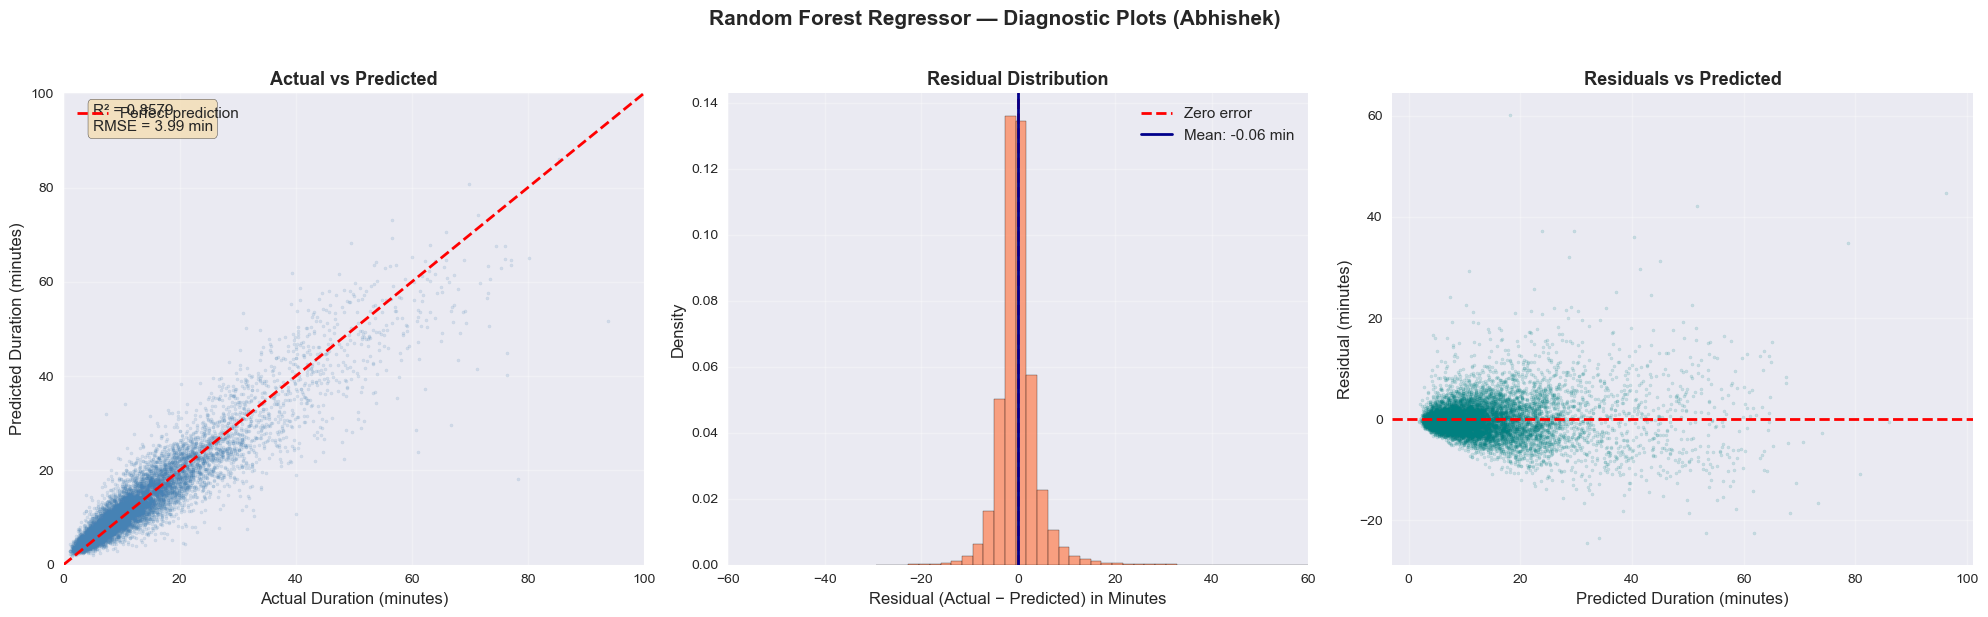

✅ Regression diagnostic plots generated!


In [29]:
# ## 6. RF Regressor — Visualizations

residuals = y_dur_test - y_dur_pred_test
n_plot = min(10000, len(y_dur_test))
idx = np.random.RandomState(42).choice(len(y_dur_test), size=n_plot, replace=False)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Random Forest Regressor — Diagnostic Plots (Abhishek)', 
             fontsize=15, fontweight='bold', y=1.02)

# Plot 1: Actual vs Predicted
axes[0].scatter(np.array(y_dur_test)[idx], y_dur_pred_test[idx], 
                alpha=0.15, s=5, color='steelblue')
axes[0].plot([0, 100], [0, 100], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Duration (minutes)', fontsize=12)
axes[0].set_ylabel('Predicted Duration (minutes)', fontsize=12)
axes[0].set_title('Actual vs Predicted', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)
axes[0].set_xlim(0, 100)
axes[0].set_ylim(0, 100)
axes[0].text(0.05, 0.92, f'R² = {reg_test_r2:.4f}\nRMSE = {reg_test_rmse:.2f} min', 
             transform=axes[0].transAxes, fontsize=11,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Plot 2: Residual Distribution
axes[1].hist(residuals, bins=80, color='coral', edgecolor='black', alpha=0.7, density=True)
axes[1].axvline(0, color='red', linewidth=2, linestyle='--', label='Zero error')
axes[1].axvline(np.mean(residuals), color='darkblue', linewidth=2, linestyle='-',
                label=f'Mean: {np.mean(residuals):.2f} min')
axes[1].set_xlabel('Residual (Actual − Predicted) in Minutes', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('Residual Distribution', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)
axes[1].set_xlim(-60, 60)

# Plot 3: Residuals vs Predicted
axes[2].scatter(y_dur_pred_test[idx], np.array(residuals)[idx], 
                alpha=0.15, s=5, color='teal')
axes[2].axhline(0, color='red', linewidth=2, linestyle='--')
axes[2].set_xlabel('Predicted Duration (minutes)', fontsize=12)
axes[2].set_ylabel('Residual (minutes)', fontsize=12)
axes[2].set_title('Residuals vs Predicted', fontsize=13, fontweight='bold')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("✅ Regression diagnostic plots generated!")

RF REGRESSOR — FEATURE IMPORTANCE

Features ranked by importance:

  trip_distance                   0.8438  ████████████████████████████████████████████████████████████████████████████████████
  pickup_hour                     0.0298  ██
  DOLocationID                    0.0286  ██
  time_of_day                     0.0209  ██
  PULocationID                    0.0207  ██
  time_slot                       0.0173  █
  hour_x_dayofweek                0.0098  
  dropoff_borough                 0.0058  
  is_rush_hour                    0.0050  
  pickup_day_of_week              0.0042  
  is_airport_trip                 0.0031  
  pickup_borough                  0.0028  
  is_same_borough                 0.0016  
  ratecode_name                   0.0016  
  passenger_count                 0.0014  
  is_weekend                      0.0011  
  is_single_passenger             0.0009  
  is_airport_pickup               0.0008  
  RatecodeID                      0.0005  
  distance_category    

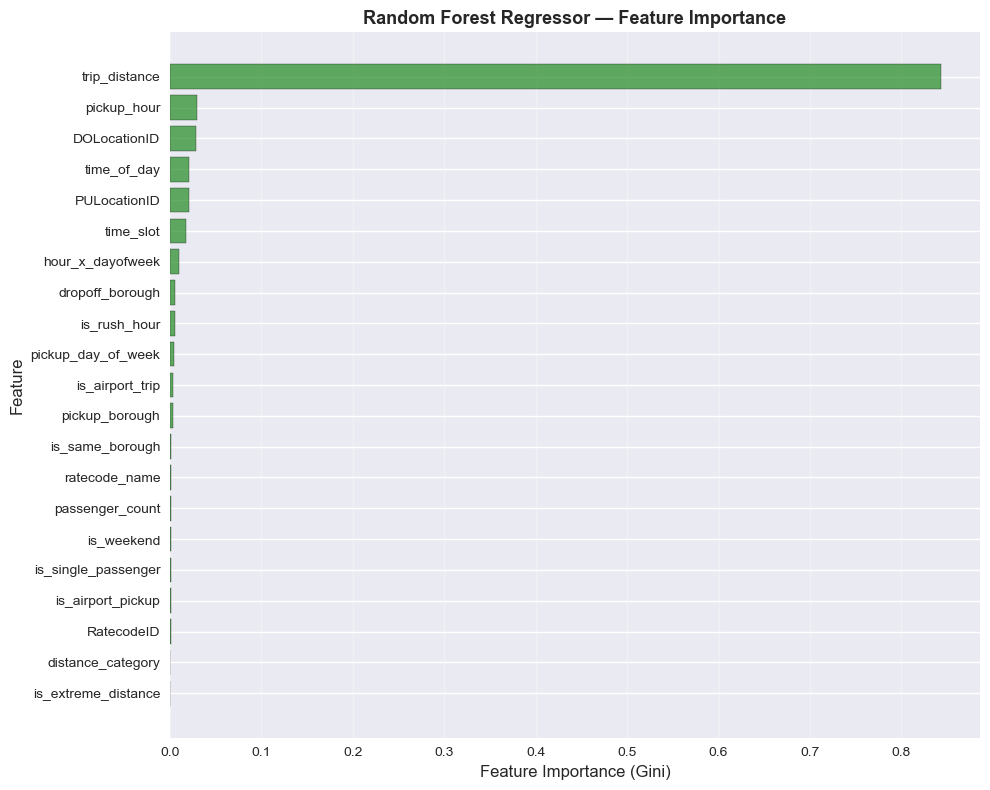

✅ Feature importance analysis complete!


In [30]:
# ---
# ## 7. RF Regressor — Feature Importance

print("="*60)
print("RF REGRESSOR — FEATURE IMPORTANCE")
print("="*60)

reg_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_reg.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeatures ranked by importance:\n")
for _, row in reg_importance.iterrows():
    bar = "█" * int(row['Importance'] * 100)
    print(f"  {row['Feature']:30s}  {row['Importance']:.4f}  {bar}")

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(reg_importance['Feature'], reg_importance['Importance'], 
        color='forestgreen', edgecolor='black', alpha=0.7)
ax.set_xlabel('Feature Importance (Gini)', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title('Random Forest Regressor — Feature Importance', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("✅ Feature importance analysis complete!")

In [31]:
# # PART B: Random Forest Classifier — Congestion Fee Prediction
# 
# Using the same train/test split and features. Random Forest should perform 
# much better than Logistic Regression here because congestion fee exposure 
# is fundamentally a location-based decision — tree-based models can learn 
# sharp decision boundaries around specific zones.
#
# Using `class_weight='balanced'` to handle the ~74/26 class imbalance, 
# with light regularization to control overfitting.


In [32]:
# ---
# ## 8. Train RF Classifier

print("="*60)
print("PART B: RANDOM FOREST CLASSIFIER — CONGESTION FEE")
print("="*60)

rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=30,              # Prevent full-depth memorization
    min_samples_leaf=5,        # Require at least 5 samples per leaf
    class_weight='balanced',   # Handle ~74/26 class imbalance
    random_state=42,
    n_jobs=-1
)

print("⏳ Training Random Forest Classifier...")
rf_clf.fit(X_train, y_cong_train)
print("✅ Model trained!")
print(f"   Settings: n_estimators=100, max_depth=30, min_samples_leaf=5, class_weight='balanced'")

PART B: RANDOM FOREST CLASSIFIER — CONGESTION FEE
⏳ Training Random Forest Classifier...
✅ Model trained!
   Settings: n_estimators=100, max_depth=30, min_samples_leaf=5, class_weight='balanced'


In [33]:
# ## 9. RF Classifier — Evaluation

# Predictions
y_cong_pred = rf_clf.predict(X_test)
y_cong_proba = rf_clf.predict_proba(X_test)[:, 1]

# Metrics
clf_accuracy = accuracy_score(y_cong_test, y_cong_pred)
clf_auc = roc_auc_score(y_cong_test, y_cong_proba)
clf_f1 = f1_score(y_cong_test, y_cong_pred)

# Naive baseline accuracy (always predict majority class)
naive_accuracy = y_cong_test.value_counts(normalize=True).max()

print("="*60)
print("RF CLASSIFIER — RESULTS")
print("="*60)

print(f"\n  Accuracy:  {clf_accuracy:.4f}")
print(f"  AUC:       {clf_auc:.4f}")
print(f"  F1 Score:  {clf_f1:.4f}")

print(f"\n📊 BASELINE COMPARISONS:")
print(f"   Naive (always predict YES): Accuracy = {naive_accuracy*100:.1f}%")
print(f"   Logistic Regression:        Accuracy = 75.9%, AUC = 0.695 (initial baseline)")
print(f"   Random Forest:              Accuracy = {clf_accuracy*100:.1f}%, AUC = {clf_auc:.3f}")

lr_acc_improvement = ((clf_accuracy - 0.759) / 0.759) * 100
lr_auc_improvement = ((clf_auc - 0.695) / 0.695) * 100
print(f"\n   RF improvement over Logistic Regression:")
print(f"   Accuracy: {lr_acc_improvement:+.1f}% | AUC: {lr_auc_improvement:+.1f}%")

# Overfitting check
y_cong_pred_train = rf_clf.predict(X_train)
train_accuracy = accuracy_score(y_cong_train, y_cong_pred_train)
acc_gap = abs(train_accuracy - clf_accuracy)
print(f"\n📊 OVERFITTING CHECK: Train Accuracy = {train_accuracy:.4f}, Test Accuracy = {clf_accuracy:.4f}, Gap = {acc_gap:.4f}")
if acc_gap < 0.02:
    print(f"   ✅ No overfitting")
elif acc_gap < 0.05:
    print(f"   ⚠️ Moderate gap — Moses can tune further")
else:
    print(f"   ❌ Significant overfitting — further regularization needed")

# Classification Report
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_cong_test, y_cong_pred, 
                            target_names=["No Fee (0)", "Has Fee (1)"]))


RF CLASSIFIER — RESULTS

  Accuracy:  0.9533
  AUC:       0.9794
  F1 Score:  0.9684

📊 BASELINE COMPARISONS:
   Naive (always predict YES): Accuracy = 74.4%
   Logistic Regression:        Accuracy = 75.9%, AUC = 0.695 (initial baseline)
   Random Forest:              Accuracy = 95.3%, AUC = 0.979

   RF improvement over Logistic Regression:
   Accuracy: +25.6% | AUC: +40.9%

📊 OVERFITTING CHECK: Train Accuracy = 0.9637, Test Accuracy = 0.9533, Gap = 0.0104
   ✅ No overfitting

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  No Fee (0)       0.89      0.93      0.91     25625
 Has Fee (1)       0.98      0.96      0.97     74375

    accuracy                           0.95    100000
   macro avg       0.93      0.95      0.94    100000
weighted avg       0.95      0.95      0.95    100000



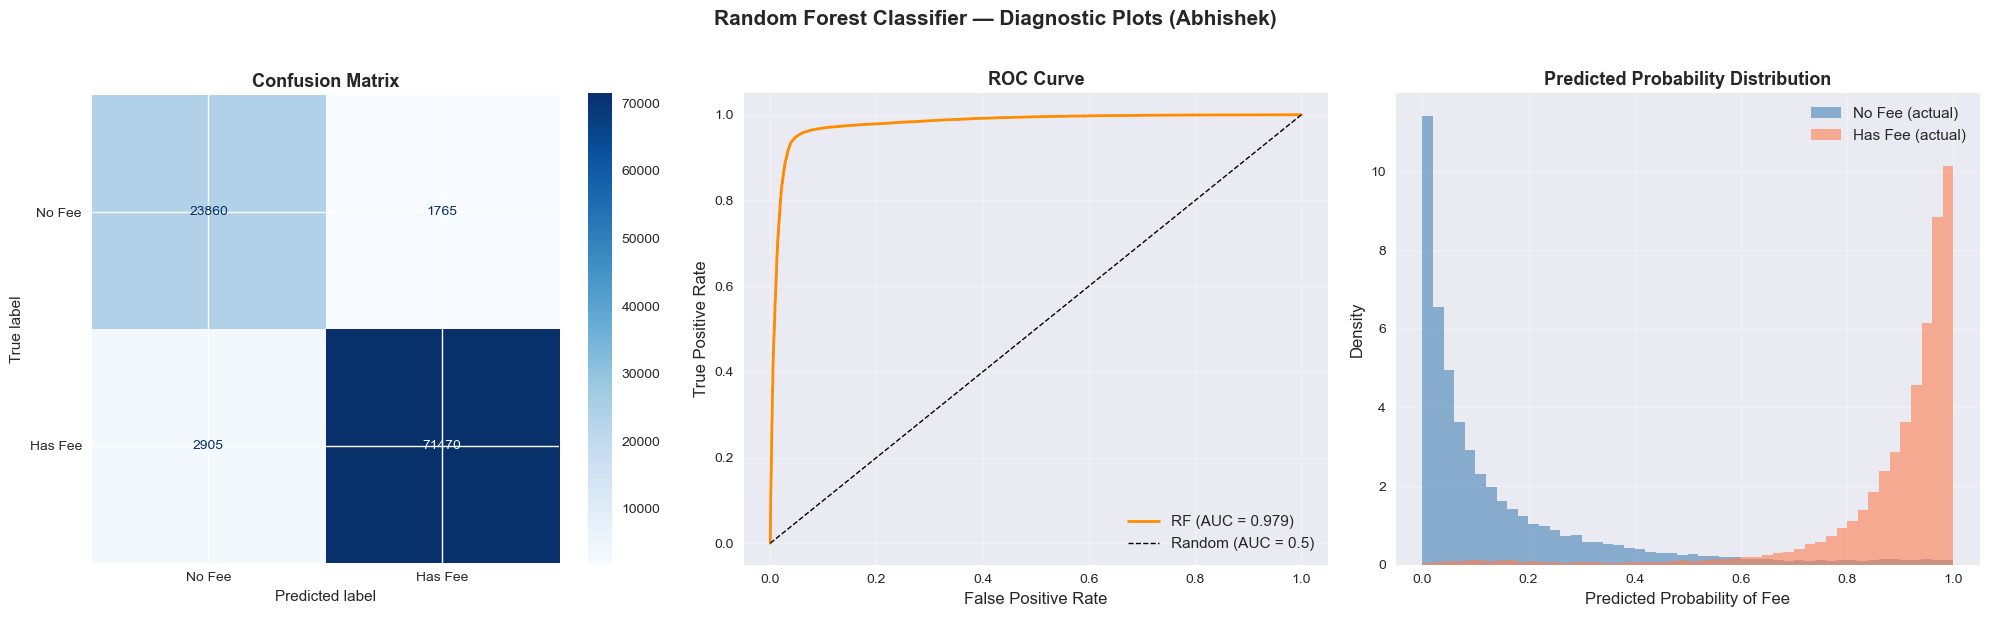

✅ Classification diagnostic plots generated!


In [34]:
# ---
# ## 10. RF Classifier — Visualizations

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Random Forest Classifier — Diagnostic Plots (Abhishek)', 
             fontsize=15, fontweight='bold', y=1.02)

# Plot 1: Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_cong_test, y_cong_pred,
    display_labels=["No Fee", "Has Fee"],
    cmap='Blues',
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')

# Plot 2: ROC Curve
fpr, tpr, _ = roc_curve(y_cong_test, y_cong_proba)
axes[1].plot(fpr, tpr, color='darkorange', linewidth=2, label=f'RF (AUC = {clf_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

# Plot 3: Predicted Probability Distribution
axes[2].hist(y_cong_proba[y_cong_test == 0], bins=50, alpha=0.6, 
             color='steelblue', label='No Fee (actual)', density=True)
axes[2].hist(y_cong_proba[y_cong_test == 1], bins=50, alpha=0.6, 
             color='coral', label='Has Fee (actual)', density=True)
axes[2].set_xlabel('Predicted Probability of Fee', fontsize=12)
axes[2].set_ylabel('Density', fontsize=12)
axes[2].set_title('Predicted Probability Distribution', fontsize=13, fontweight='bold')
axes[2].legend(fontsize=11)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("✅ Classification diagnostic plots generated!")

RF CLASSIFIER — FEATURE IMPORTANCE

Features ranked by importance:

  PULocationID                    0.4001  ████████████████████████████████████████
  DOLocationID                    0.3266  ████████████████████████████████
  trip_distance                   0.0807  ████████
  pickup_borough                  0.0350  ███
  dropoff_borough                 0.0269  ██
  is_airport_pickup               0.0204  ██
  distance_category               0.0194  █
  is_airport_trip                 0.0153  █
  pickup_hour                     0.0150  █
  time_slot                       0.0119  █
  hour_x_dayofweek                0.0102  █
  time_of_day                     0.0091  
  is_same_borough                 0.0079  
  ratecode_name                   0.0047  
  pickup_day_of_week              0.0044  
  RatecodeID                      0.0041  
  passenger_count                 0.0026  
  is_extreme_distance             0.0020  
  is_single_passenger             0.0016  
  is_rush_hour         

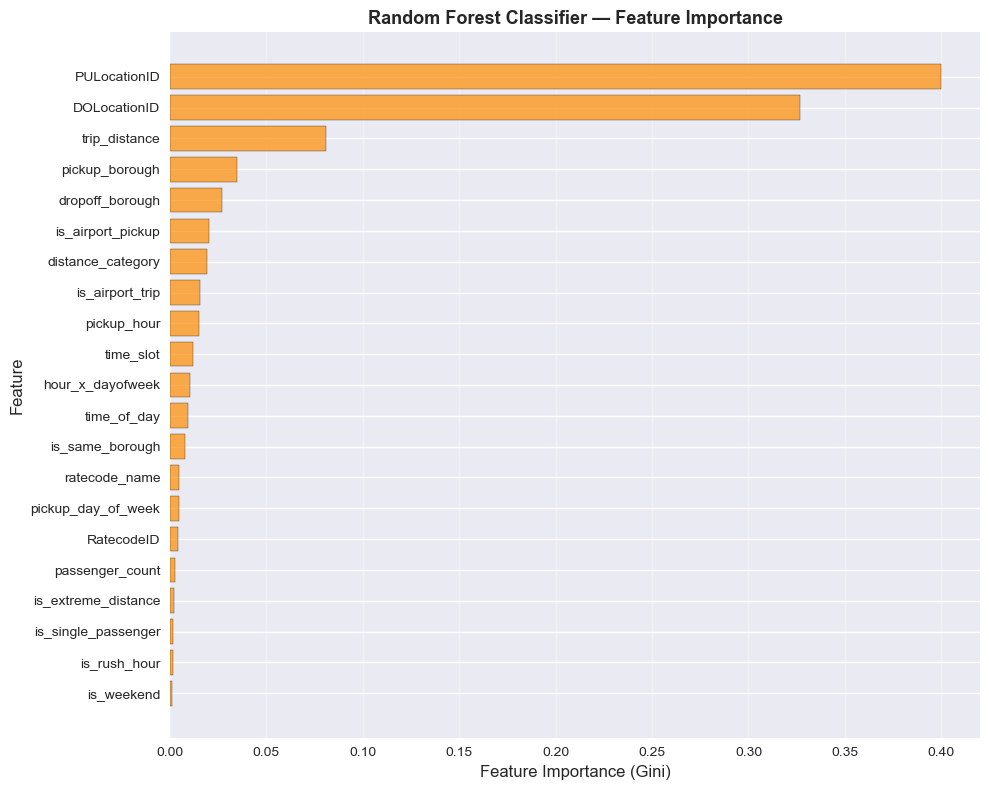

✅ Feature importance analysis complete!


In [35]:
# ---
# ## 11. RF Classifier — Feature Importance

# %%
print("="*60)
print("RF CLASSIFIER — FEATURE IMPORTANCE")
print("="*60)

clf_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_clf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeatures ranked by importance:\n")
for _, row in clf_importance.iterrows():
    bar = "█" * int(row['Importance'] * 100)
    print(f"  {row['Feature']:30s}  {row['Importance']:.4f}  {bar}")

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(clf_importance['Feature'], clf_importance['Importance'], 
        color='darkorange', edgecolor='black', alpha=0.7)
ax.set_xlabel('Feature Importance (Gini)', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title('Random Forest Classifier — Feature Importance', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("✅ Feature importance analysis complete!")


In [36]:
# ## 12. Combined Results Summary

print("="*70)
print("COMBINED RESULTS — RANDOM FOREST (Starter Pipeline)")
print("="*70)

print(f"\n  Settings: n_estimators=100, max_depth=30, min_samples_leaf=5")
print(f"  Sample: {SAMPLE_SIZE:,} trips | Split: 80/20 | Stratified on congestion fee")

print(f"\n{'─'*70}")
print(f"  PART A: TRIP DURATION (Regression)")
print(f"{'─'*70}")
print(f"\n  {'Model':<28} {'RMSE':>8} {'MAE':>8} {'R²':>8}")
print(f"  {'─'*52}")
print(f"  {'Naive (predict mean)':<28} {naive_rmse:>8.2f} {'—':>8} {'—':>8}")
print(f"  {'Linear Regression':<28} {'5.45':>8} {'3.75':>8} {'0.7386':>8}")
print(f"  {'Random Forest':<28} {reg_test_rmse:>8.2f} {reg_test_mae:>8.2f} {reg_test_r2:>8.4f}")
print(f"\n  Stakeholder Goal (RMSE < 10): {'✅ ACHIEVED' if reg_test_rmse < 10 else '❌ NOT YET'}")

print(f"\n{'─'*70}")
print(f"  PART B: CONGESTION FEE (Classification)")
print(f"{'─'*70}")
print(f"\n  {'Model':<28} {'Accuracy':>10} {'AUC':>8} {'F1':>8}")
print(f"  {'─'*54}")
print(f"  {'Naive (predict YES)':<28} {naive_accuracy*100:>9.1f}% {'—':>8} {'—':>8}")
print(f"  {'Logistic Regression':<28} {'75.9%':>10} {'0.695':>8} {'—':>8}")
print(f"  {'Random Forest':<28} {clf_accuracy*100:>9.1f}% {clf_auc:>8.3f} {clf_f1:>8.3f}")

# Top features comparison
print(f"\n{'─'*70}")
print(f"  TOP 5 FEATURES BY MODEL")
print(f"{'─'*70}")
print(f"\n  {'#':<4} {'Regression (Duration)':<30} {'Classification (Congestion Fee)'}")
print(f"  {'─'*64}")
for i in range(5):
    reg_feat = reg_importance.iloc[i]
    clf_feat = clf_importance.iloc[i]
    print(f"  {i+1:<4} {reg_feat['Feature']:<30} {clf_feat['Feature']}")

print(f"""
{'─'*70}
  NEXT STEPS
{'─'*70}
  → Moses: Tune RF hyperparameters (n_estimators, max_depth, min_samples_split)
  → Morgan: Build XGBoost starter pipelines for both tasks
  → Tarun: Tune Morgan's XGBoost
  → Final: Merge best RF vs best XGB comparison table
""")

print("="*70)
print("✅ Abhishek's Random Forest starter pipelines complete!")
print("="*70)

COMBINED RESULTS — RANDOM FOREST (Starter Pipeline)

  Settings: n_estimators=100, max_depth=30, min_samples_leaf=5
  Sample: 500,000 trips | Split: 80/20 | Stratified on congestion fee

──────────────────────────────────────────────────────────────────────
  PART A: TRIP DURATION (Regression)
──────────────────────────────────────────────────────────────────────

  Model                            RMSE      MAE       R²
  ────────────────────────────────────────────────────
  Naive (predict mean)            10.59        —        —
  Linear Regression                5.45     3.75   0.7386
  Random Forest                    3.99     2.61   0.8579

  Stakeholder Goal (RMSE < 10): ✅ ACHIEVED

──────────────────────────────────────────────────────────────────────
  PART B: CONGESTION FEE (Classification)
──────────────────────────────────────────────────────────────────────

  Model                          Accuracy      AUC       F1
  ──────────────────────────────────────────────────────